# Blinkit Case Study

In [ ]:
import pandas as pd
import numpy as np

!gdown 1ZdhRqYv-JizWV6DxO6C4R_k1kxPhmlF2


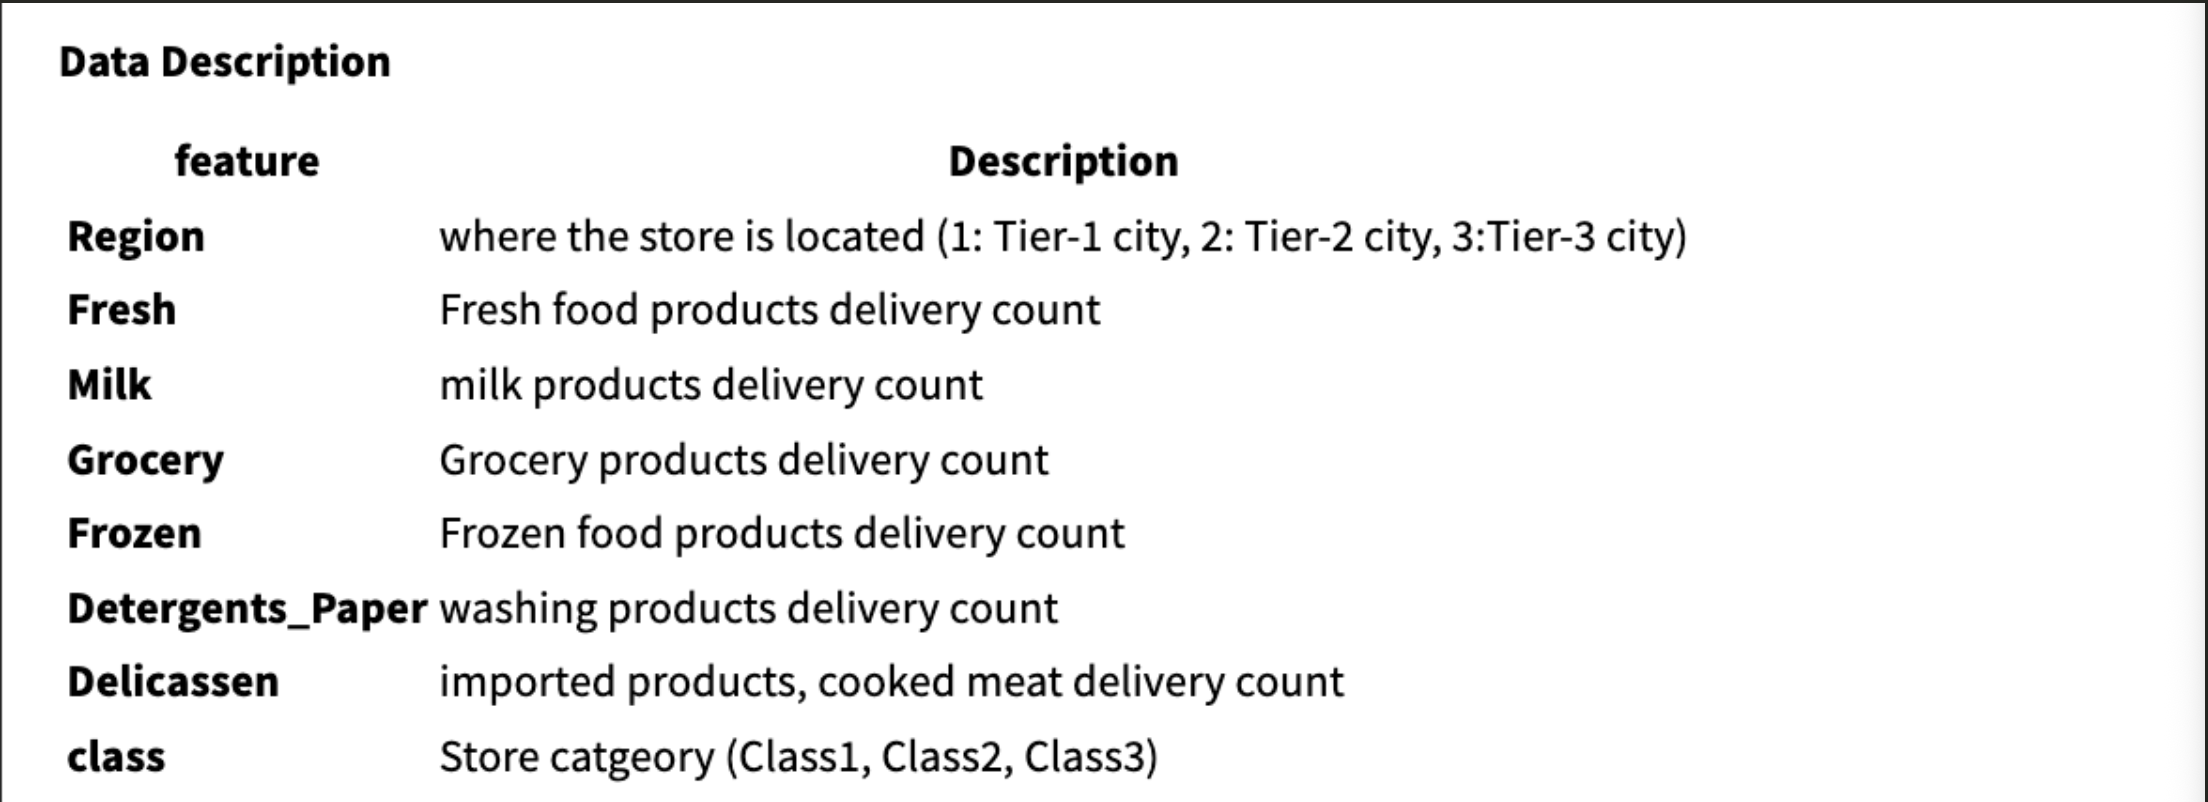

In [2]:
df = pd.read_csv('multiclass.csv')
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


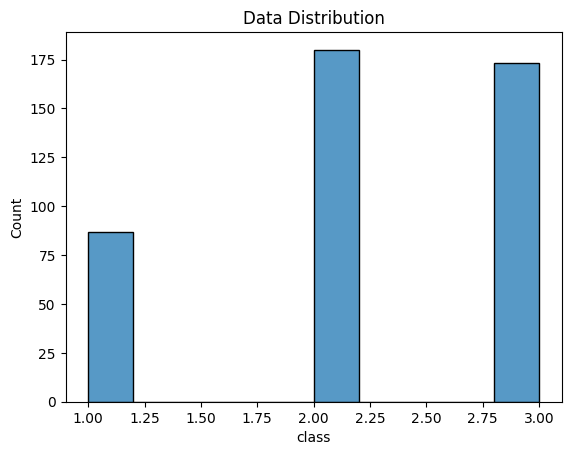

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="class")
plt.title('Data Distribution')
plt.show()

In [4]:
X=df[['Region', 'Fresh',    'Milk', 'Grocery',  'Frozen',   'Detergents_Paper', 'Delicassen'    ]].copy()
y=df[['class']].copy()

In [5]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


X_train_val, X_test, y_train_val, y_test = train_test_split(X,y,test_size=0.25, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val,y_train_val,test_size=0.25, random_state=42)

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(247, 7) (247, 1)
(83, 7) (83, 1)
(110, 7) (110, 1)


With any distance based model, you should always standardize data.

If you know the range of the features, CAN use minmaxscaler, StandardScaler otherwise


In [6]:
from sklearn.preprocessing import StandardScaler


std =  StandardScaler()

X_train_scaled = std.fit_transform(X_train)
X_val_scaled = std.transform(X_val.values)
X_test_scaled = std.transform(X_test.values)

y_train = y_train.values[:,0]
y_val = y_val.values[:,0]
y_test = y_test.values[:,0]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [7]:
df.head()

,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,class
0,3,12669,9656,7561,214,2674,1338,2
1,3,7057,9810,9568,1762,3293,1776,2
2,3,6353,8808,7684,2405,3516,7844,2
3,3,13265,1196,4221,6404,507,1788,1
4,3,22615,5410,7198,3915,1777,5185,1


In [8]:
X_val_scaled[50]

array([ 0.65073249, -0.49151135, -0.48436111, -0.6888578 , -0.29269993,
       -0.54361718, -0.26957321])

In [9]:
y_val[50]

np.int64(3)

In [11]:
np.sqrt(np.sum(X_val_scaled[50] - X_train_scaled[0])**2) ## Euclidean Distance

np.float64(4.052836961334906)

In [12]:
np.sum((X_val_scaled[50] - X_train_scaled)**2,axis=1)[:10]

array([ 7.25262962,  1.20929523, 14.41717958,  1.61865137,  0.44320402,
        8.39261813,  0.46000898,  0.23585462,  4.05776375,  0.25102321])

In [14]:
a = np.array([2, 4])
b = np.array([5, 6])
print((a-b)**2)
print(np.sum((a-b)**2))
print(np.sqrt(np.sum((a-b)**2)))

[9 4]
13
3.605551275463989


In [15]:
dist = np.sqrt(np.sum((X_val_scaled[50] - X_train_scaled)**2, axis=1))
dist.shape

(247,)

In [16]:
distances = [(dist[i], y_train[i]) for i in range(len(X_train))]

distances[:5]

[(np.float64(2.6930706679191183), np.int64(2)),
 (np.float64(1.099679602476764), np.int64(1)),
 (np.float64(3.796996125733141), np.int64(2)),
 (np.float64(1.2722623030554996), np.int64(3)),
 (np.float64(0.6657356972011926), np.int64(3))]

In [20]:
sorted_distances = sorted(distances)
top_5_distance = sorted_distances[:5]

top_5_distance

[(np.float64(0.19275661488858367), np.int64(3)),
 (np.float64(0.2027784716985357), np.int64(3)),
 (np.float64(0.2159416502390324), np.int64(3)),
 (np.float64(0.2673329164659889), np.int64(3)),
 (np.float64(0.28247298555212313), np.int64(3))]

In [21]:
for cl in top_5_distance:
  print(cl[1])

3
3
3
3
3


In [22]:
from sklearn.neighbors import KNeighborsClassifier


# Create a KNN classifier instance
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model on the scaled training data
knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [23]:
# Make predictions on the scaled validation data
sklearn_predictions = knn_model.predict(X_val_scaled)

print("Predictions from scikit-learn KNN model:")
print(sklearn_predictions)

Predictions from scikit-learn KNN model:
[3 2 2 2 3 2 3 1 3 3 2 2 3 3 2 3 3 3 2 3 1 1 2 2 1 2 3 2 2 2 2 3 2 2 2 3 2
 1 3 3 3 3 1 2 3 2 1 3 2 3 3 2 3 3 2 2 3 3 3 1 1 2 1 3 3 2 2 1 3 2 2 2 2 2
 3 2 1 3 1 2 3 3 2]


In [24]:
from sklearn.metrics import accuracy_score

sklearn_accuracy = accuracy_score(y_val, sklearn_predictions)

print(f"Accuracy of the scikit-learn KNN model on the validation set: {sklearn_accuracy}")

Accuracy of the scikit-learn KNN model on the validation set: 0.9156626506024096


Text(0, 0.5, 'Accuracy')

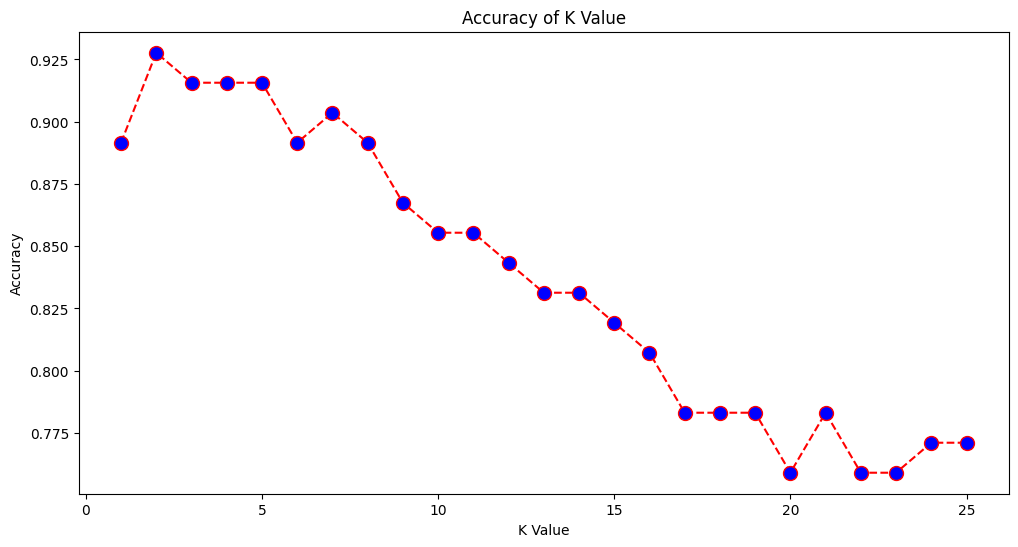

In [25]:
Acc = []

for i in range(1, 51, 2):
  knn = KNeighborsClassifier(n_neighbors=i)

  # Train the model on the scaled training data
  knn.fit(X_train_scaled, y_train)

  Acc.append(knn.score(X_val_scaled,y_val))



plt.figure(figsize=(12, 6))
plt.plot(range(1, 26), Acc, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Accuracy of K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')





